# Мультимодальный RAG: Обыкновенные дифференциальные уравнения

**Документ:** В. И. Арнольд — «Обыкновенные дифференциальные уравнения» (344 стр.)  
**Содержание:** Фазовые пространства, линейные уравнения, теоремы существования, формулы, графики  
**Пайплайн:** PyMuPDF → BlockClassifier → CLIP → ChartAnalyzer (OCR+BLIP+GPT) → SBERT → FAISS → RAG

---
## 1. Настройка среды

In [1]:
import sys, os, logging, time, gc
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

logging.basicConfig(level=logging.INFO, format='%(name)s - %(message)s')

PDF_PATH = 'data/input_pdfs/odu-12.pdf'
print(f'PDF: {os.path.basename(PDF_PATH)}')
print(f'Size: {os.path.getsize(PDF_PATH) / 1024 / 1024:.1f} MB')

print('\n=== Зависимости ===')
try:
    import pytesseract
    print(f'Tesseract: v{pytesseract.get_tesseract_version()}')
except Exception:
    print('Tesseract: НЕ УСТАНОВЛЕН')
import fitz
print(f'PyMuPDF: v{fitz.version[0]}')
print(f'Страниц: {len(fitz.open(PDF_PATH))}')

PDF: odu-12.pdf
Size: 4.6 MB

=== Зависимости ===
Tesseract: v5.5.0
PyMuPDF: v1.27.2
Страниц: 344


---
## 2. Этап 1 — Извлечение блоков

PyMuPDF + BlockClassifier → header, text, list, table, no_text

In [2]:
import fitz
from src.pipeline.page_analyzer import PageAnalyzer
from collections import Counter

t0 = time.time()
doc = fitz.open(PDF_PATH)
analyzer = PageAnalyzer()

all_blocks = []
for page_num in range(len(doc)):
    page = doc[page_num]
    blocks = analyzer.analyze_page(page, page_num + 1)
    all_blocks.extend(blocks)
doc.close()

elapsed = time.time() - t0
type_counts = Counter(b.block_type for b in all_blocks)
print(f'Блоков: {len(all_blocks)} за {elapsed:.1f} сек')
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t:10s}: {c}')

Блоков: 4982 за 7.8 сек
  text      : 3071
  no_text   : 1229
  table     : 587
  header    : 70
  list      : 25


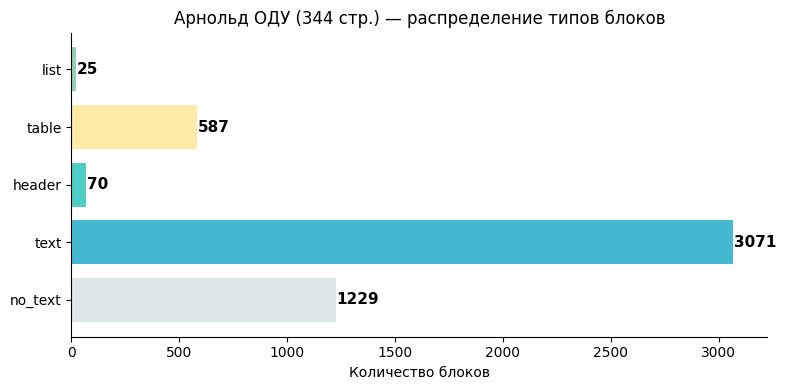

In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(8, 4))
types = list(type_counts.keys())
counts = list(type_counts.values())
colors_map = {
    'header': '#4ECDC4', 'text': '#45B7D1', 'list': '#96CEB4',
    'table': '#FFEAA7', 'no_text': '#DFE6E9', 'chart': '#FF6B6B',
    'image': '#A29BFE'
}
bar_colors = [colors_map.get(t, '#95A5A6') for t in types]
bars = ax.barh(types, counts, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Количество блоков')
ax.set_title('Арнольд ОДУ (344 стр.) — распределение типов блоков')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
os.makedirs('report/img', exist_ok=True)
plt.savefig('report/img/odu_block_types.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Примеры блоков
print('ПРИМЕРЫ БЛОКОВ ПО ТИПАМ')
print('=' * 50)
shown = set()
for block in all_blocks:
    if block.block_type not in shown and block.text:
        shown.add(block.block_type)
        preview = block.text[:150].replace('\n', ' ')
        if len(block.text) > 150: preview += '...'
        print(f'\n[{block.block_type:10s}] Стр. {block.page_num}:')
        print(f'  {preview}')

ПРИМЕРЫ БЛОКОВ ПО ТИПАМ

[text      ] Стр. 2:
  Издание подготовлено при поддержке Фонда Дмитрия Зимина «Династия»

[header    ] Стр. 4:
  УДК . ББК .. А

[table     ] Стр. 5:
  Г л а в а   .   Основные   понятия   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .  § 1.   Фазовые пространства...

[no_text   ] Стр. 39:
  .

[list      ] Стр. 61:
  1)  R  → R ,   x   7→ e x ; 2)  R  → R ,   x   7→ x 3 ; 3)  C  → C ,   z  7→ z 3 ?


---
## 3. Этап 2 — Извлечение и классификация изображений (CLIP)

> **max_images=20** для экономии памяти.  
> CLIP выгружается после классификации.

In [5]:
from src.preprocessing.image_extractor import ImageExtractor

t0 = time.time()
extractor = ImageExtractor(min_width=80, min_height=80)
doc_name = os.path.splitext(os.path.basename(PDF_PATH))[0]
images_dir = os.path.join('data/images', doc_name)

extracted_images = extractor.extract_from_pdf(
    PDF_PATH, output_dir=images_dir, max_images=20
)
del extractor
gc.collect()
print(f'Извлечено: {len(extracted_images)} изображений за {time.time()-t0:.1f} сек')

src.preprocessing.image_extractor - Извлечение изображений из: data/input_pdfs/odu-12.pdf (344 страниц, лимит: 20)
src.preprocessing.image_extractor - Достигнут лимит: 20 изображений


Извлечено: 20 изображений за 1.6 сек


In [6]:
from src.preprocessing.image_captioner import ImageClassifier

chart_images = []
photo_images = []

if extracted_images:
    t0 = time.time()
    classifier = ImageClassifier(use_clip=True)
    classifications = classifier.classify_batch(extracted_images)

    chart_images = [
        (img, cls) for img, cls in zip(extracted_images, classifications)
        if cls['block_type'] == 'chart'
    ]
    photo_images = [
        (img, cls) for img, cls in zip(extracted_images, classifications)
        if cls['block_type'] == 'image'
    ]

    print(f'CLIP: {time.time()-t0:.1f} сек')
    print(f'Charts: {len(chart_images)}, Images: {len(photo_images)}')
    for i, (img, cls) in enumerate(zip(extracted_images, classifications)):
        print(f'  [{i+1}] Стр. {img.page_num+1}: {cls["block_type"]:5s} '
              f'(chart={cls["chart_score"]:.3f}, image={cls["image_score"]:.3f})')

    del classifier
    gc.collect()
    print('CLIP выгружен.')
else:
    print('Изображения не найдены.')

src.preprocessing.image_captioner -   Классификация [1/20]: стр. 2, 1713x1600px
src.preprocessing.image_captioner - Загрузка CLIP модели (openai/clip-vit-base-patch32)...
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safete

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
httpx -

CLIP: 25.8 сек
Charts: 18, Images: 2
  [1] Стр. 2: image (chart=0.004, image=0.329)
  [2] Стр. 15: image (chart=0.083, image=0.250)
  [3] Стр. 15: chart (chart=0.319, image=0.014)
  [4] Стр. 17: chart (chart=0.218, image=0.115)
  [5] Стр. 17: chart (chart=0.314, image=0.019)
  [6] Стр. 18: chart (chart=0.303, image=0.030)
  [7] Стр. 20: chart (chart=0.319, image=0.015)
  [8] Стр. 21: chart (chart=0.328, image=0.005)
  [9] Стр. 21: chart (chart=0.328, image=0.005)
  [10] Стр. 22: chart (chart=0.330, image=0.003)
  [11] Стр. 23: chart (chart=0.333, image=0.000)
  [12] Стр. 24: chart (chart=0.333, image=0.001)
  [13] Стр. 25: chart (chart=0.310, image=0.023)
  [14] Стр. 25: chart (chart=0.332, image=0.002)
  [15] Стр. 27: chart (chart=0.331, image=0.002)
  [16] Стр. 27: chart (chart=0.320, image=0.013)
  [17] Стр. 30: chart (chart=0.311, image=0.022)
  [18] Стр. 31: chart (chart=0.268, image=0.066)
  [19] Стр. 31: chart (chart=0.317, image=0.016)
  [20] Стр. 31: chart (chart=0.321, image=

---
## 4. Этап 3 — Транскрипция графиков (OCR + BLIP + GPT)

In [7]:
from src.preprocessing.chart_analyzer import ChartAnalyzer
from src.preprocessing.ocr_processor import OCRProcessor

chart_only_images = [img for img, cls in chart_images][:5]
chart_results = []

if chart_only_images:
    ocr = OCRProcessor()
    chart_analyzer = ChartAnalyzer(
        ocr_processor=ocr, use_clip=True, use_blip=True, use_opencv=True,
    )
    t0 = time.time()
    chart_results = chart_analyzer.analyze_batch(chart_only_images)
    print(f'{len(chart_results)} графиков за {time.time()-t0:.1f} сек')

    for i, r in enumerate(chart_results):
        print(f'\n--- График {i+1} (стр. {r.page_num}) ---')
        print(f'  Подтип: {r.chart_subtype_ru}')
        if r.blip_caption: print(f'  BLIP: {r.blip_caption[:80]}')
        if r.ocr_text: print(f'  OCR: {r.ocr_text[:100]}')
        if r.gpt_description: print(f'  GPT: {r.gpt_description[:150]}')

    del chart_analyzer, ocr
    gc.collect()
    print('\nМодели выгружены.')
else:
    print('Графики не найдены.')

src.preprocessing.chart_analyzer -   Анализ графика [1/5]: стр. 15, 917x558px
src.preprocessing.chart_analyzer - Загрузка CLIP для анализа графиков...
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/generation_config.json "HTTP/1.1 404 Not Found"
httpx - HTTP Request: HEAD https://huggingface.co/Salesforce/blip-image-captioning-large/resolve/main/config.json "HTTP/1.1 307 Temporary Re

5 графиков за 69.5 сек

--- График 1 (стр. 15) ---
  Подтип: Точечная диаграмма
  BLIP: this image shows a diagram of a square with a line of intersection
  OCR: / Машины
  GPT: **Тип визуализации**: точечная диаграмма (scatter plot).  
**Что отображается**: точки, расположенные внутри квадрата, что, по описанию BLIP, представ

--- График 2 (стр. 17) ---
  Подтип: Точечная диаграмма
  BLIP: this image shows a diagram of a cell line
  OCR: ~o. о Ча
о -ы со A 545
= ъ%
о- -9-790.-4 С
  GPT: Тип визуализации – точечная диаграмма (scatter plot).  
На графике

--- График 3 (стр. 17) ---
  Подтип: Точечная диаграмма
  BLIP: this image shows a diagram of a football play with a line of play
  OCR: < ом
қ5ч»-- ЖҘ
RN wow J
  GPT: 1. Визуализация представляет собой точечную диаграмму.  
2. На схеме изображён футбольный разыгрыш с линией нападения, где точки обозначают позиции иг

--- График 4 (стр. 18) ---
  Подтип: Точечная диаграмма
  BLIP: this image shows a diagram of a circle with a point at 

---
## 5. Визуализация: Оригинал → Транскрипция

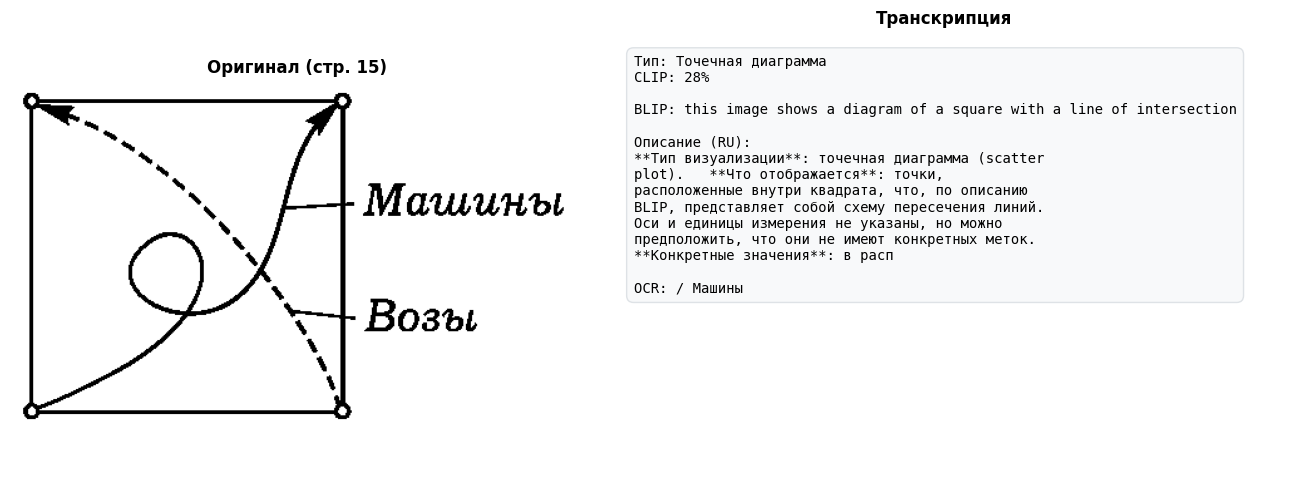

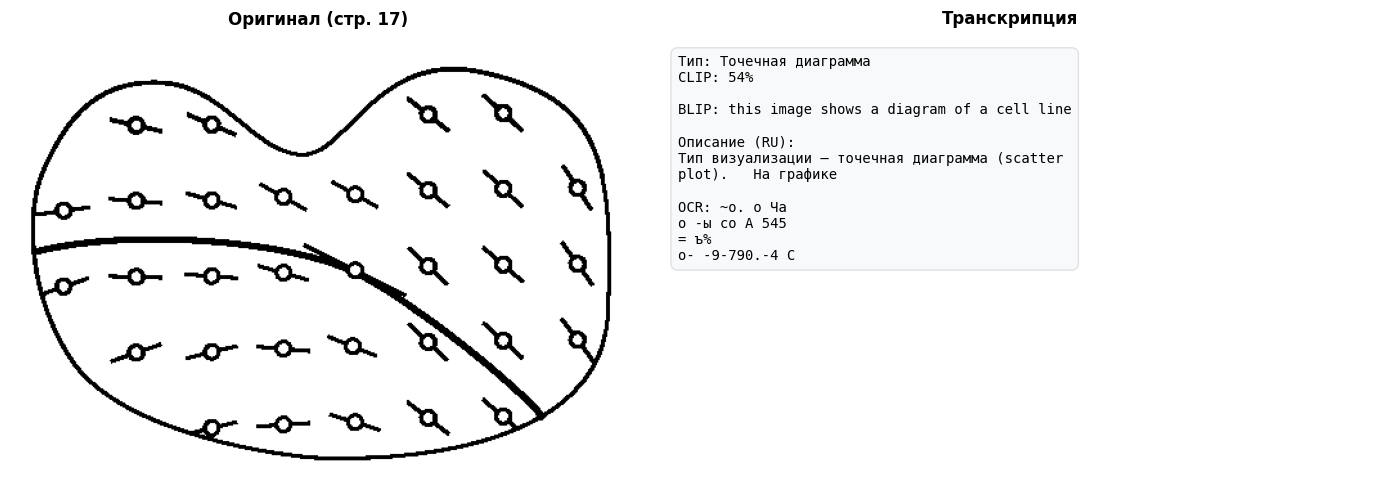

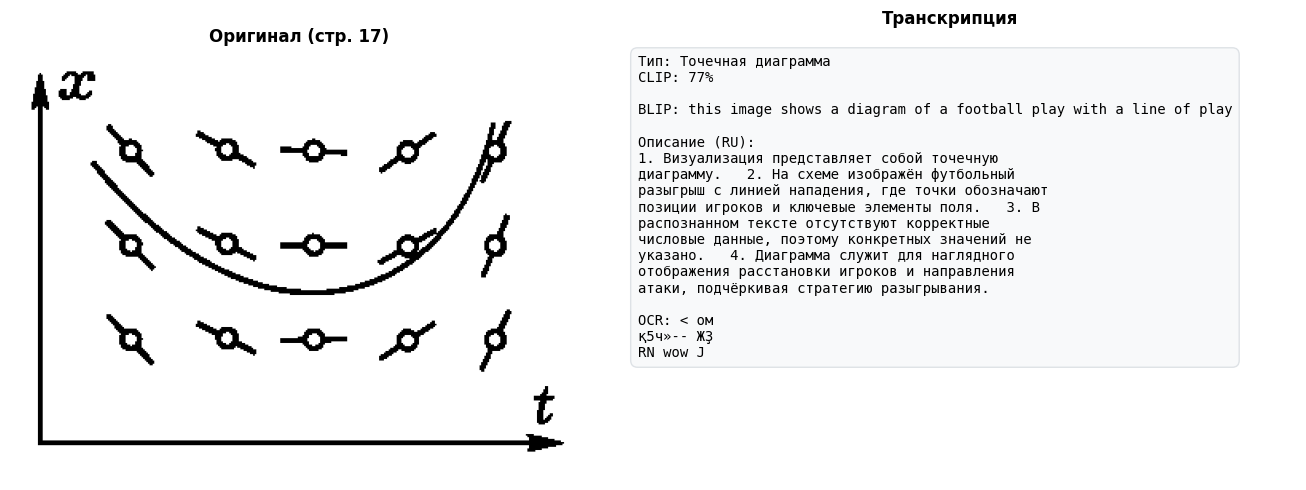

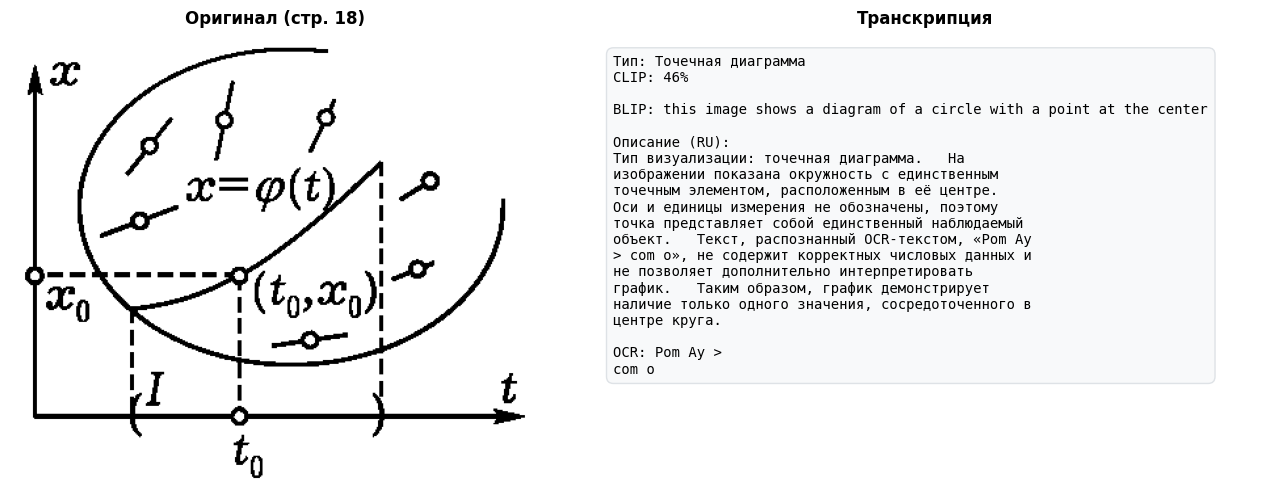

14568

In [8]:
import textwrap

if chart_results and chart_only_images:
    for idx in range(min(len(chart_results), 4)):
        img_data = chart_only_images[idx]
        a = chart_results[idx]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                        gridspec_kw={'width_ratios': [1, 1.2]})
        ax1.imshow(img_data.image); ax1.axis('off')
        ax1.set_title(f'Оригинал (стр. {a.page_num})', fontweight='bold')
        ax2.axis('off')
        lines = [f"Тип: {a.chart_subtype_ru}", f"CLIP: {a.confidence:.0%}", ""]
        if a.blip_caption: lines += [f"BLIP: {a.blip_caption}", ""]
        if a.gpt_description:
            lines += ["Описание (RU):", textwrap.fill(a.gpt_description, 50), ""]
        if a.ocr_text: lines.append(f"OCR: {a.ocr_text[:150]}")
        ax2.text(0.05, 0.95, "\n".join(lines), transform=ax2.transAxes,
                va='top', fontsize=10, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.5', fc='#F8F9FA', ec='#DEE2E6'))
        ax2.set_title('Транскрипция', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'report/img/odu_chart_{idx+1}.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Нет графиков.')

del extracted_images
gc.collect()

---
## 6. Markdown и Chunking

In [9]:
from src.preprocessing.markdown_builder import MarkdownBuilder
from src.rag.chunker import MarkdownChunker
from src.layout.block import Block

chart_blocks = []
for img_data, analysis in zip(chart_only_images, chart_results):
    chart_blocks.append(Block(
        block_type='chart', bbox=img_data.bbox,
        page_num=img_data.page_num + 1,
        text=analysis.to_chunk_text(), metadata=analysis.to_dict(),
    ))

image_blocks = []
for img_data, cls in photo_images:
    image_blocks.append(Block(
        block_type='image', bbox=img_data.bbox,
        page_num=img_data.page_num + 1,
        metadata={'image_path': img_data.saved_path or '', 'ocr_text': ''},
    ))

final_blocks = all_blocks + chart_blocks + image_blocks
print(f'Итого: {len(final_blocks)} (текст: {len(all_blocks)}, графики: {len(chart_blocks)}, фото: {len(image_blocks)})')

builder = MarkdownBuilder()
source_name = os.path.basename(PDF_PATH)
markdown = builder.build(final_blocks, source_name)
md_dir = os.path.join('data/indexes', doc_name)
os.makedirs(md_dir, exist_ok=True)
builder.save(markdown, os.path.join(md_dir, source_name + '.md'))
print(f'Markdown: {len(markdown)} символов')

chunker = MarkdownChunker(max_chunk_size=1000, chunk_overlap=100, min_chunk_size=50)
chunks = chunker.chunk_markdown(markdown, source=source_name)
print(f'Чанков: {len(chunks)}')

del markdown, final_blocks, all_blocks
gc.collect()

src.preprocessing.markdown_builder - Markdown saved to data/indexes/odu-12/odu-12.pdf.md
src.rag.chunker - Created 1024 chunks from 'odu-12.pdf'


Итого: 4989 (текст: 4982, графики: 5, фото: 2)
Markdown: 873006 символов
Чанков: 1024


0

In [10]:
# Пример чанка
found = False
for c in chunks:
    if 'график' in c.text.lower() or 'диаграмма' in c.text.lower() or 'фазов' in c.text.lower():
        print('=== Чанк с визуальным контентом ===')
        print(c.text[:500])
        found = True
        break
if not found:
    print('Пример текстового чанка:')
    print(chunks[0].text[:500])

=== Чанк с визуальным контентом ===
За   сорок   лет,   прошедших   со   времени   выхода   первого   издания,   этот учебник успел стать классическим. Большое внимание уделяется геометри- ческому   смыслу   основных   понятий.   В   книге   прослеживается   тесная   связь предмета с приложениями, в особенности с механикой. При изложении де- лается упор не на формулы, а на геометрический смысл основных определе- ний и теорем. Автор знакомит читателя с такими понятиями, как многооб- разия,   однопараметрические группы   диффеоморфи


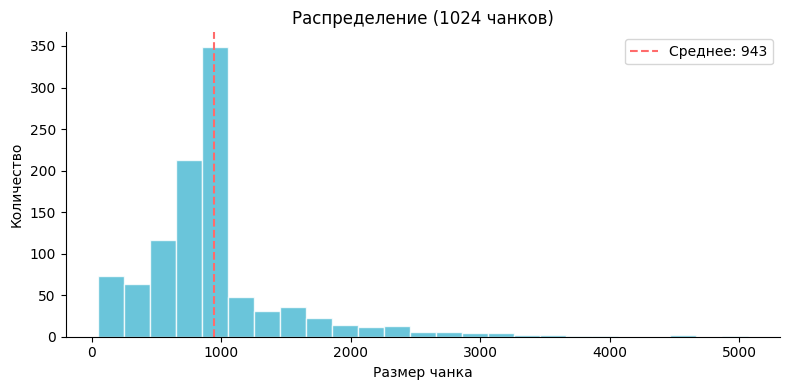

In [11]:
sizes = [len(c.text) for c in chunks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=25, color='#45B7D1', edgecolor='white', alpha=0.8)
ax.axvline(x=sum(sizes)/len(sizes), color='#FF6B6B', linestyle='--',
           label=f'Среднее: {sum(sizes)/len(sizes):.0f}')
ax.set_xlabel('Размер чанка')
ax.set_ylabel('Количество')
ax.set_title(f'Распределение ({len(chunks)} чанков)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('report/img/odu_chunk_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Эмбеддинги и FAISS

In [12]:
from src.rag.embedder import MultimodalEmbedder
from src.rag.vector_store import FAISSVectorStore

t0 = time.time()
embedder = MultimodalEmbedder(use_clip=False)
embeddings = embedder.embed_chunks(chunks)
print(f'Эмбеддинги: {embeddings.shape} за {time.time()-t0:.1f} сек')

vector_store = FAISSVectorStore(dimension=embedder.dimension)
vector_store.add(embeddings, [c.to_dict() for c in chunks])
index_dir = os.path.join('data/indexes', doc_name)
vector_store.save(index_dir)
print(f'Индекс: {vector_store.size} чанков')

faiss.loader - Loading faiss with AVX2 support.
faiss.loader - Successfully loaded faiss with AVX2 support.
src.rag.embedder - Loading text embedding model: paraphrase-multilingual-MiniLM-L12-v2
sentence_transformers.SentenceTransformer - Use pytorch device_name: cpu
sentence_transformers.SentenceTransformer - Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingfac

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config.json "HTTP/1.1 200 OK"
httpx - HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-

Эмбеддинги: (1024, 384) за 91.3 сек
Индекс: 1024 чанков


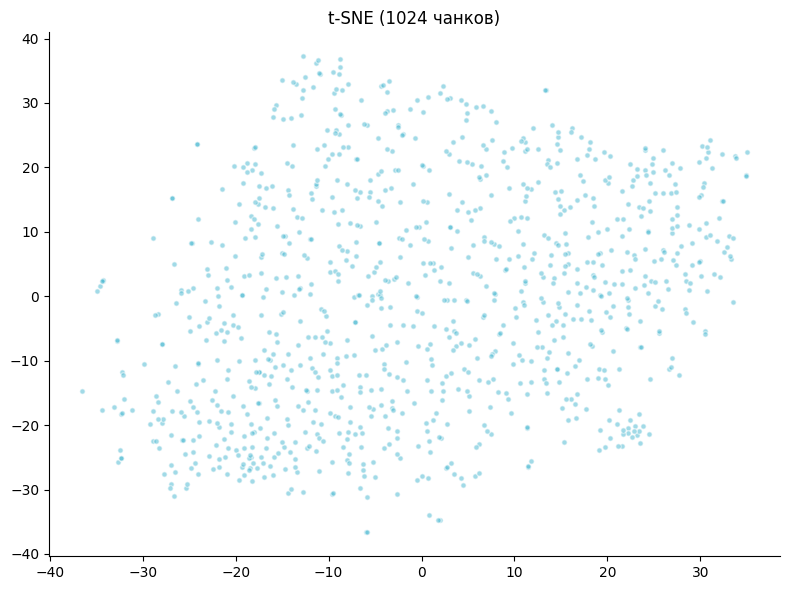

In [13]:
from sklearn.manifold import TSNE

if embeddings.shape[0] > 5:
    perp = min(30, embeddings.shape[0] - 1)
    coords = TSNE(n_components=2, random_state=42, perplexity=perp).fit_transform(embeddings)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(coords[:, 0], coords[:, 1], c='#45B7D1', alpha=0.5, s=15, edgecolors='white')
    ax.set_title(f't-SNE ({embeddings.shape[0]} чанков)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('report/img/odu_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. RAG: Вопрос-Ответ

**6 вопросов:**
- 2 общих
- 2 по теме (дифф. уравнения, теоремы)
- 2 по графикам и формулам

In [14]:
from src.rag.retriever import MultimodalRetriever
from src.rag.generator import RAGGenerator

retriever = MultimodalRetriever(embedder=embedder, vector_store=vector_store, top_k=5)
generator = RAGGenerator(model_name='gpt-oss-20b')
print(f'LLM доступен: {generator.is_available()}')

def ask(question):
    print(f'\n{"="*60}')
    print(f'Вопрос: {question}')
    print(f'{"="*60}')
    results = retriever.retrieve(question, top_k=5)
    parts = [f'[{i}]:\n{r["text"]}' for i, r in enumerate(results, 1)]
    context = '\n\n---\n\n'.join(parts)
    result = generator.generate(question, context)
    print(f'\nОтвет ({result["model"]}):')
    print(result['answer'])
    for i, r in enumerate(results[:3], 1):
        print(f'  [{i}] Стр.{r.get("page","?")}, score={r.get("score",0):.4f}')
    return result

LLM доступен: True


### Общие вопросы

In [15]:
q1 = ask('О чём этот документ? Кратко опиши структуру и основные темы.')

src.rag.retriever - Retrieved 5 chunks for query: 'О чём этот документ? Кратко опиши структуру и осно...' (filter=None)



Вопрос: О чём этот документ? Кратко опиши структуру и основные темы.

Ответ (gpt-oss-20b):
Документ — учебник (или монография) по дифференциальным уравнениям и геометрии динамических систем.  

**Краткая структура и основные темы**

1. **Введение и оглавление** – на странице 6 указано содержание, а также отмечено, что книга предназначена для студентов и аспирантов.  
2. **Глава «Основные понятия»** – на страницах 13‑16 рассматриваются фундаментальные определения: фазовые пространства, размерность фазового пространства для систем из n материальных точек, векторное поле фазовой скорости, фазовые кривые и их свойства.  
3. **Геометрический подход** – подчёркивается внимание к геометрическому смыслу: многообразия, однопараметрические группы диффеоморфизмов, касательные пространства и расслоения.  
4. **Применения к механике** – приводятся примеры из классической механики: фазовые портреты консервативных систем с одной степенью свободы, теория малых колебаний, параметрический резонанс.  
5

In [16]:
q2 = ask('Для какой аудитории написан этот учебник и какие предварительные знания требуются?')

src.rag.retriever - Retrieved 5 chunks for query: 'Для какой аудитории написан этот учебник и какие п...' (filter=None)



Вопрос: Для какой аудитории написан этот учебник и какие предварительные знания требуются?

Ответ (gpt-oss-20b):
Учебник ориентирован на **студентов и аспирантов математических факультетов университетов и вузов с расширенной программой по математике**.  

**Предварительные знания, которые ожидаются от читателя:**

- базовый курс дифференциальных уравнений (обыкновенных и, в частности, линейных автономных систем);
- основы линейной алгебры (группы линейных преобразований, собственные значения и т.д.);
- базовый анализ (производные, интегралы, ряды Тейлора);
- геометрический подход к математике (геометрический смысл основных понятий, касательные пространства и т.п.).
  [1] Стр.None, score=0.5606
  [2] Стр.5, score=0.5493
  [3] Стр.5, score=0.4362


### Вопросы по теме

In [17]:
q3 = ask('Сформулируй теорему существования и единственности решения обыкновенного дифференциального уравнения.')

src.rag.retriever - Retrieved 5 chunks for query: 'Сформулируй теорему существования и единственности...' (filter=None)



Вопрос: Сформулируй теорему существования и единственности решения обыкновенного дифференциального уравнения.

Ответ (gpt-oss-20b):
**Теорема о существовании и единственности решения обыкновенного дифференциального уравнения**

Пусть задано обыкновенное дифференциальное уравнение  
\[
y'=f(t,y), \qquad (t,y)\in D\subset\mathbb R^{2},
\]
где \(f\) непрерывна на прямоугольнике  
\[
D=\{(t,y)\mid t_{0}-a\le t\le t_{0}+a,\; y_{0}-b\le y\le y_{0}+b\}
\]
и удовлетворяет условию Липшица по переменной \(y\); то есть существует число \(L>0\) такое, что  
\[
|f(t,y_{1})-f(t,y_{2})|\le L|y_{1}-y_{2}|\quad\text{для всех }(t,y_{1}),(t,y_{2})\in D.
\]

Тогда для любой начальной точки \((t_{0},y_{0})\in D\) существует интервал \((t_{0}-h,t_{0}+h)\subset[t_{0}-a,t_{0}+a]\) и единственное решение \(y(t)\) дифференциального уравнения, удовлетворяющее условию  
\[
y(t_{0})=y_{0},
\]
определённое на этом интервале.  

Эта теорема (также известная как теорема Пикара‑Линделяф–Болцано) доказывается с помощь

In [18]:
q4 = ask('Что такое фазовое пространство и фазовые кривые? Как они связаны с решениями дифференциальных уравнений?')

src.rag.retriever - Retrieved 5 chunks for query: 'Что такое фазовое пространство и фазовые кривые? К...' (filter=None)



Вопрос: Что такое фазовое пространство и фазовые кривые? Как они связаны с решениями дифференциальных уравнений?

Ответ (gpt-oss-20b):
**Фазовое пространство** – это совокупность всех возможных состояний рассматриваемой динамической системы.  
В контексте документа это пространство обычно представляется как набор координат, которые полностью описывают состояние системы (например, координата и скорость маятника, координаты \(x\) и \(y\) в системе \(\dot x=g(x),\ \dot y=f(y)\), или цилиндрический фазовый портрет маятника).

**Фазовые кривые** – это траектории, которые система проходит в фазовом пространстве при выполнении своих динамических уравнений. В тексте указано, что:

- «Фазовые кривые системы () являются интегральными кривыми уравнения (), и, обратно, интегральные кривые уравнения () являются фазовыми кривыми системы»;
- «Тангенс угла наклона вектора фазовой скорости к оси \(x\) есть \(f(y)/g(x)\). Значит, фазовая кривая системы в каждой своей точке касается поля направлений 

### Вопросы по графикам и формулам

In [19]:
q5 = ask('Что изображено на графиках и фазовых портретах в документе? Опиши визуальные данные.')

src.rag.retriever - Retrieved 5 chunks for query: 'Что изображено на графиках и фазовых портретах в д...' (filter=None)



Вопрос: Что изображено на графиках и фазовых портретах в документе? Опиши визуальные данные.

Ответ (gpt-oss-20b):
**Графики и фазовые портреты, представленные в документе**

| № | Страница | Вид визуализации | Что изображено (по описанию) |
|---|----------|------------------|------------------------------|
| 1 | 15 | Точечная диаграмма (scatter plot) | Точки расположены внутри квадрата. По описанию BLIP это схема пересечения линий. Оси и единицы измерения не указаны, поэтому точные координаты не известны. |
| 2 | 17 | Точечная диаграмма | На графике присутствуют точки, однако OCR‑текст не даёт чётких числовых данных, поэтому конкретное содержание остаётся неясным. |
| 3 | 18 | Точечная диаграмма | Изображена окружность с единственным точечным элементом, расположенным в её центре. Оси отсутствуют, так что точка представляет собой единственный наблюдаемый объект. |
| 4 | 17 | Точечная диаграмма | На схеме изображён футбольный разыгрыш с линией нападения. Точки обозначают позиции игроко

In [20]:
q6 = ask('Какие ключевые формулы и уравнения приводятся в тексте? Приведи примеры.')

src.rag.retriever - Retrieved 5 chunks for query: 'Какие ключевые формулы и уравнения приводятся в те...' (filter=None)



Вопрос: Какие ключевые формулы и уравнения приводятся в тексте? Приведи примеры.

Ответ (gpt-oss-20b):
В тексте упоминаются несколько ключевых типов уравнений, но конкретные формулы не приводятся. Ниже перечислены те уравнения, которые явно обозначены в отрывках, и краткое описание их роли:

| № | Уравнение / формула | Краткое описание |
|---|---------------------|------------------|
| 1 | **Квазилинейное уравнение** (описано в § [1]) | Уравнение, в котором неизвестная функция входит линейно, но её производные могут входить нелинейно. В тексте отмечается, что полезно перейти от уравнения с частными производными к более удобной форме. |
| 2 | **Линейное неоднородное уравнение** (описано в § [2]) | Уравнение вида \(L[u] = f\), где \(L\) – линейный дифференциальный оператор, а \(f\) – заданная функция. В тексте упоминается «пространство решений» такого уравнения. |
| 3 | **Уравнение ()** (описано в § [3]) | Вопрос «Найти фундаментальную систему решений уравнения ()» подразумевает, что 

---
## 9. Итоговая статистика

In [21]:
import fitz as fitz2
print('=' * 50)
print('ИТОГОВАЯ СТАТИСТИКА')
print('=' * 50)
print(f'Документ:   {os.path.basename(PDF_PATH)}')
print(f'Автор:      В. И. Арнольд')
print(f'Страниц:    {len(fitz2.open(PDF_PATH))}')
print(f'Размер:     {os.path.getsize(PDF_PATH)/1024/1024:.1f} MB')
print()
print('Блоки (этап 1):')
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t:10s}: {c}')
print()
print(f'Charts: {len(chart_images)}, Images: {len(photo_images)}')
print(f'Транскрипций: {len(chart_results)}')
print(f'Чанков: {len(chunks)}, В индексе: {vector_store.size}')
print(f'Размерность: {embeddings.shape[1]}')

ИТОГОВАЯ СТАТИСТИКА
Документ:   odu-12.pdf
Автор:      В. И. Арнольд
Страниц:    344
Размер:     4.6 MB

Блоки (этап 1):
  text      : 3071
  no_text   : 1229
  table     : 587
  header    : 70
  list      : 25

Charts: 18, Images: 2
Транскрипций: 5
Чанков: 1024, В индексе: 1024
Размерность: 384
